#Dataset info :

*   Features are labled v1 .. v28 due to confidentiality issues, we cannot provide the original features and more background information about the data. Features V1, V2, … V28 are the principal components obtained with PCA, the only features which have not been transformed with PCA are 'Time' and 'Amount'.
*   Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset.
*   The feature 'Amount' is the transaction Amount, this feature can be used for example-dependant cost-sensitive learning.
*   Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

*    **Given the class imbalance ratio, we recommend measuring the accuracy using the Area Under the Precision-Recall Curve (AUPRC). Confusion matrix accuracy is not meaningful for unbalanced classification.**

*    [Dataset Link](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


In [1]:
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix,
    mean_squared_error, mean_absolute_error
)
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import numpy as np
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [2]:
file_path = "creditcard.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path,
)

<ipython-input-2-343c1a66d6fe>:3: DeprecationWarning: load_dataset is deprecated and will be removed in a future version.
  df = kagglehub.load_dataset(


In [3]:
df.dataframeName = 'creditcard.csv'

In [4]:
X = df.drop(columns = "Class")
y = df["Class"]

In [5]:
feature_names = X.columns

# Preprocessing

In [6]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

In [7]:
# 4) Split 70% train / 15% val / 15% test
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Model

In [8]:
tf.random.set_seed(42)
model = Sequential([
    LSTM(15, input_shape=(1, X_scaled.shape[2])),
    Dense(1, activation='sigmoid')
])
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    verbose=2
)

Epoch 1/100
779/779 - 6s - 8ms/step - accuracy: 0.9932 - loss: 0.0578 - val_accuracy: 0.9983 - val_loss: 0.0131
Epoch 2/100
779/779 - 6s - 8ms/step - accuracy: 0.9983 - loss: 0.0125 - val_accuracy: 0.9983 - val_loss: 0.0123
Epoch 3/100
779/779 - 3s - 4ms/step - accuracy: 0.9983 - loss: 0.0121 - val_accuracy: 0.9983 - val_loss: 0.0118
Epoch 4/100
779/779 - 3s - 4ms/step - accuracy: 0.9983 - loss: 0.0112 - val_accuracy: 0.9983 - val_loss: 0.0107
Epoch 5/100
779/779 - 5s - 6ms/step - accuracy: 0.9983 - loss: 0.0090 - val_accuracy: 0.9984 - val_loss: 0.0080
Epoch 6/100
779/779 - 3s - 4ms/step - accuracy: 0.9987 - loss: 0.0064 - val_accuracy: 0.9985 - val_loss: 0.0061
Epoch 7/100
779/779 - 3s - 4ms/step - accuracy: 0.9988 - loss: 0.0049 - val_accuracy: 0.9988 - val_loss: 0.0053
Epoch 8/100
779/779 - 4s - 5ms/step - accuracy: 0.9991 - loss: 0.0043 - val_accuracy: 0.9989 - val_loss: 0.0050
Epoch 9/100
779/779 - 4s - 5ms/step - accuracy: 0.9992 - loss: 0.0040 - val_accuracy: 0.9990 - val_loss:

In [ ]:
y_prob = model.predict(X_test).ravel()
y_pred = (y_prob > 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_prob)
mae = mean_absolute_error(y_test, y_prob)
rmse = np.sqrt(mse)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {precision:.4f}")
print(f"Recall:     {recall:.4f}")
print(f"F1 Score:   {f1:.4f}")
print(f"MSE:        {mse:.6f}")
print(f"MAE:        {mae:.6f}")
print(f"RMSE:       {rmse:.6f}")
print("Confusion Matrix:")
print(cm)

1336/1336 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Accuracy:   0.9994
Precision:  0.9032
Recall:     0.7568
F1 Score:   0.8235
MSE:        0.000491
MAE:        0.001126
RMSE:       0.022156
Confusion Matrix:
[[42642     6]
 [   18    56]]


# XAI methods

In [ ]:
!pip install alibi
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 12.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=cf5ec7b05540d3d6c1f208c807276432b68579814077ad28f9ce17d7c0cac6e1
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [ ]:
from alibi.explainers import ALE
import lime
import lime.lime_tabular
import shap

def silent_predict(x):
    x_reshaped = x.reshape((x.shape[0], 1, x.shape[1]))
    return model.predict(x_reshaped, verbose=0)

X_test_flat = X_test.reshape(X_test.shape[0], X_test.shape[2])

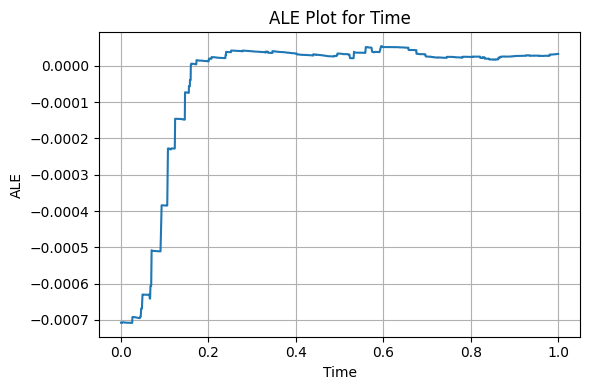

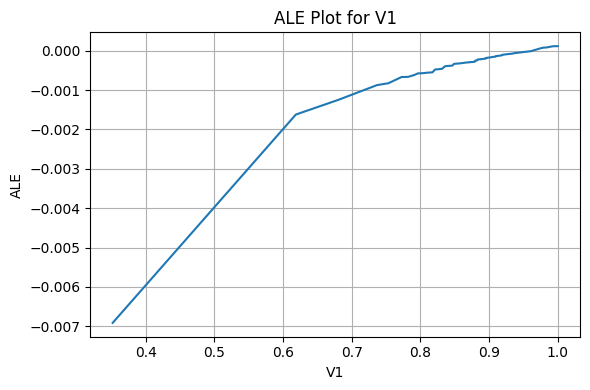

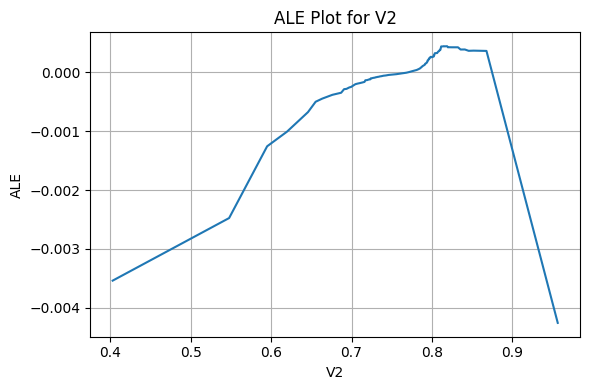

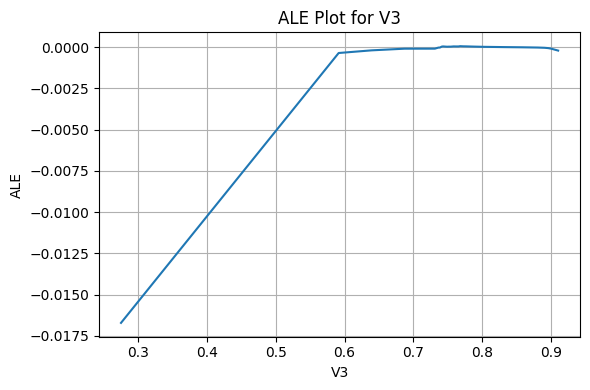

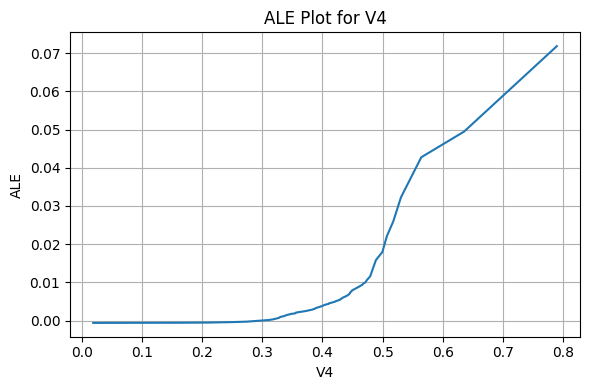

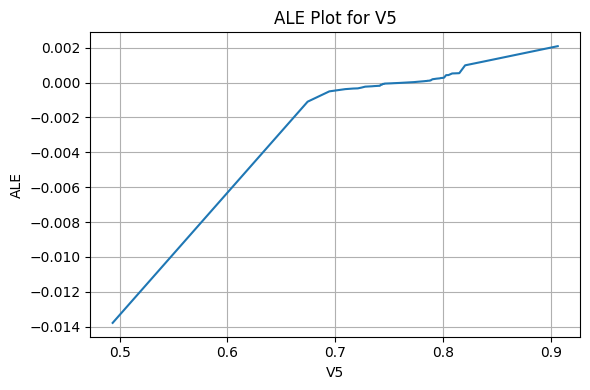

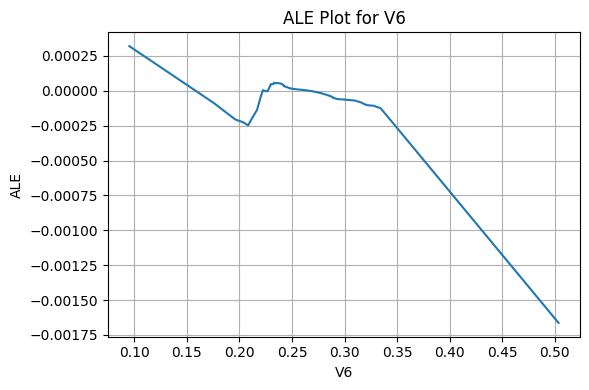

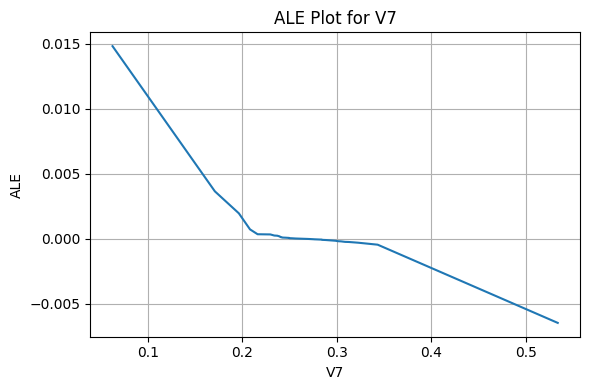

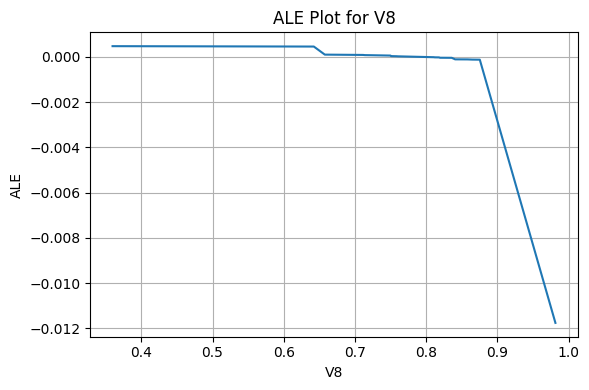

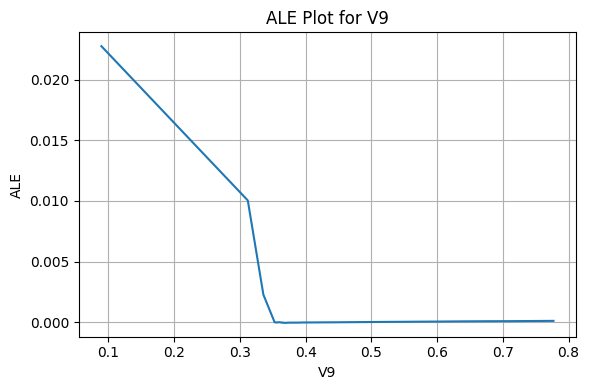

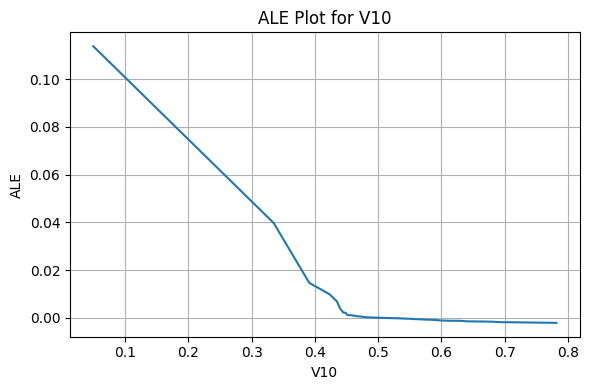

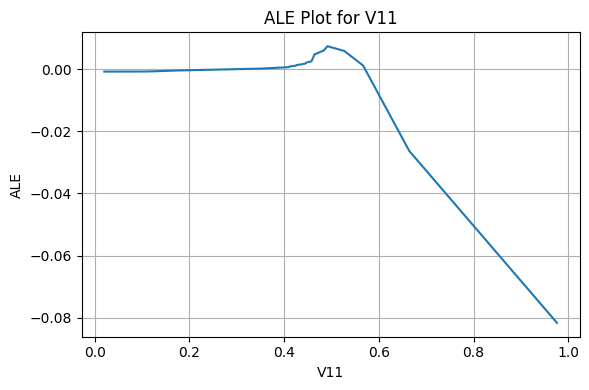

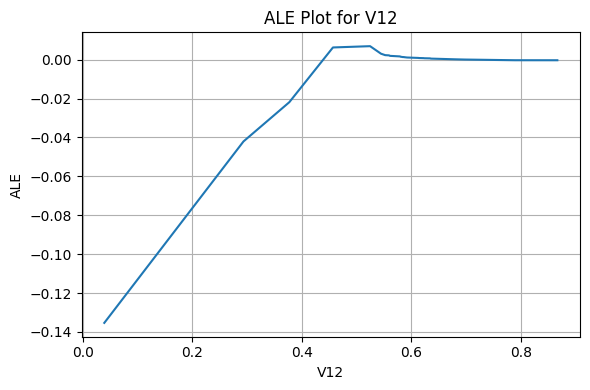

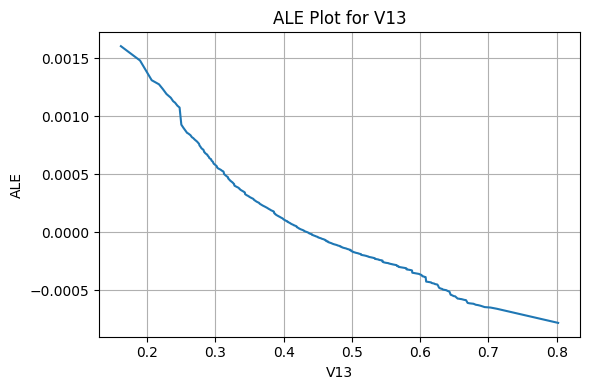

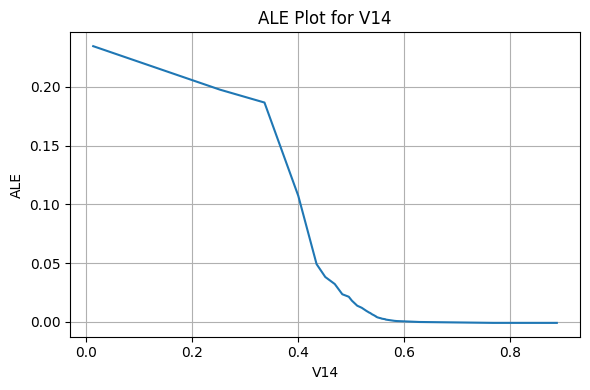

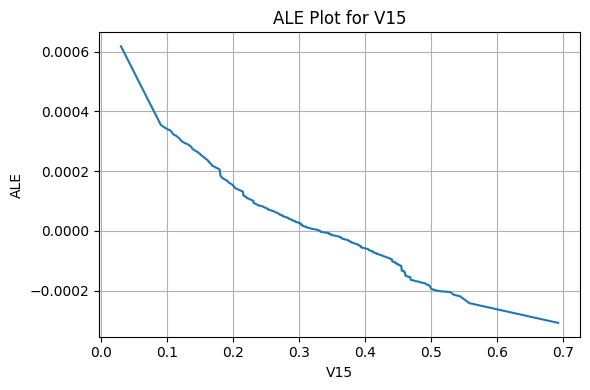

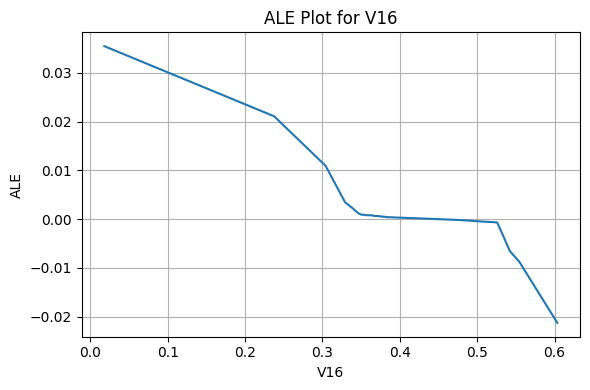

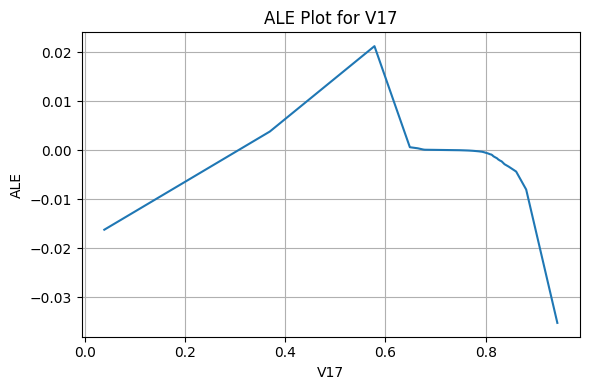

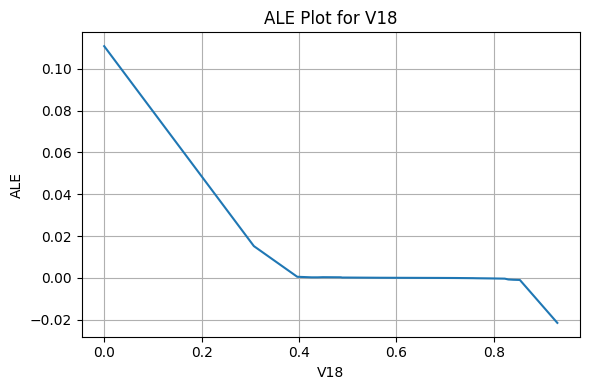

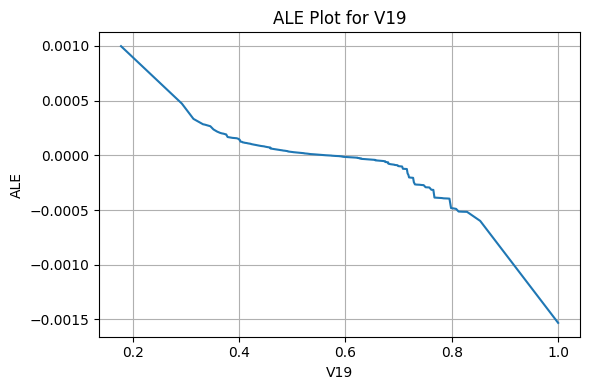

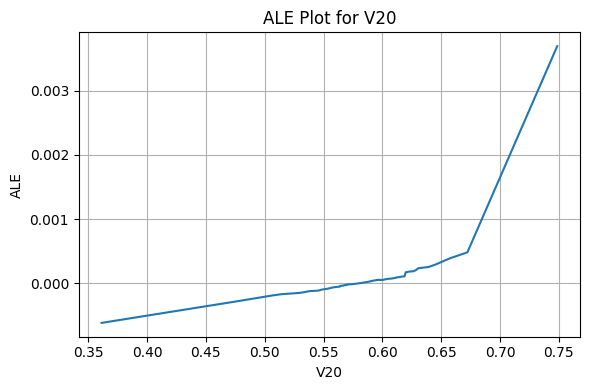

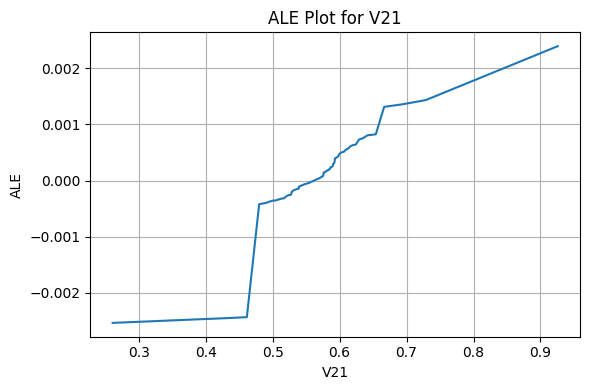

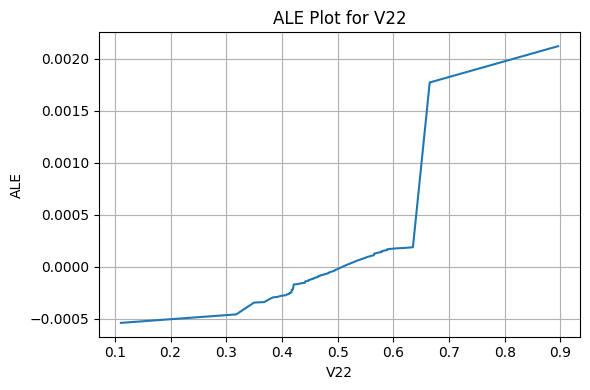

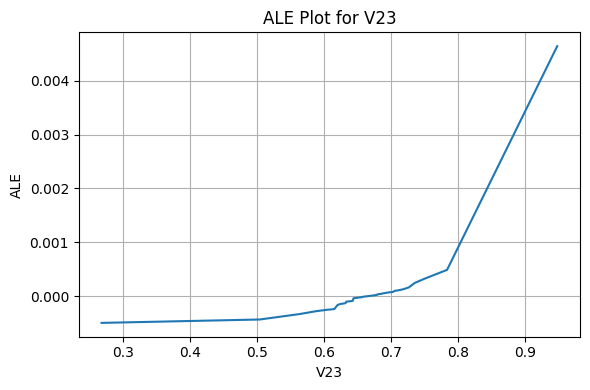

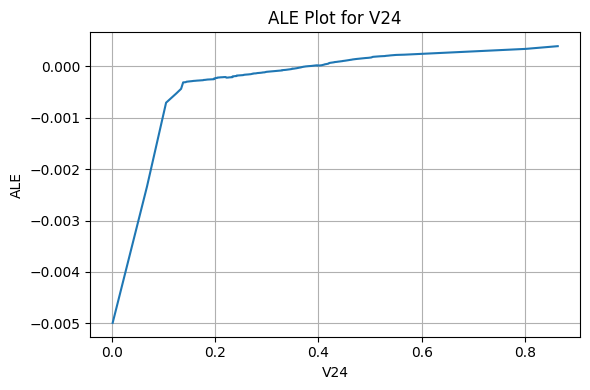

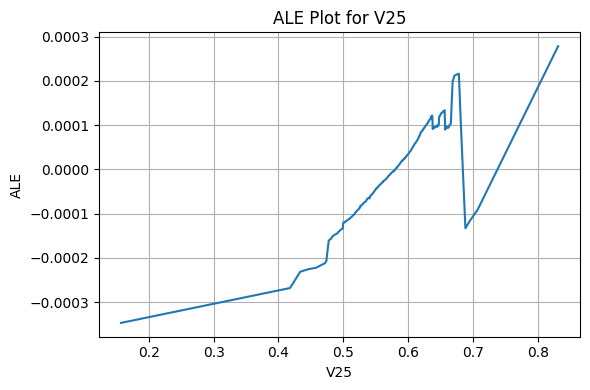

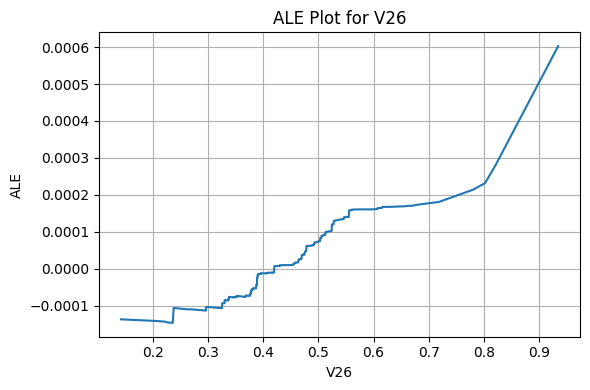

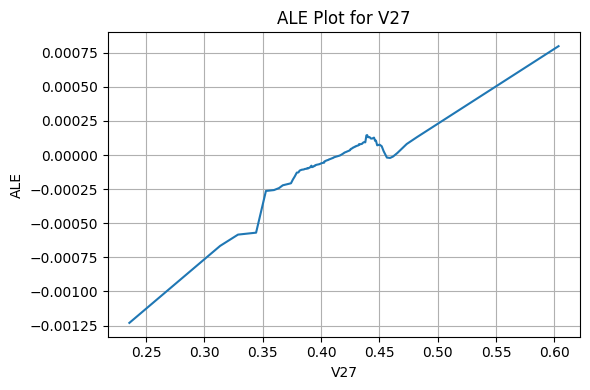

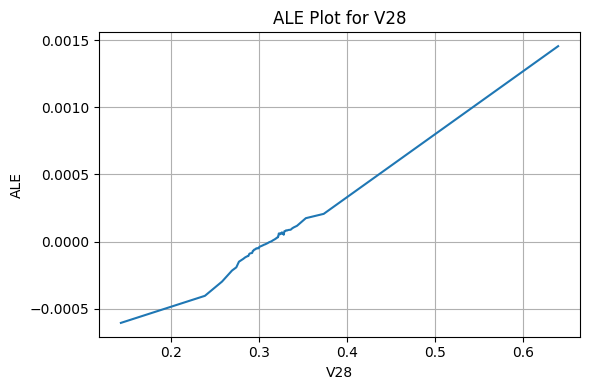

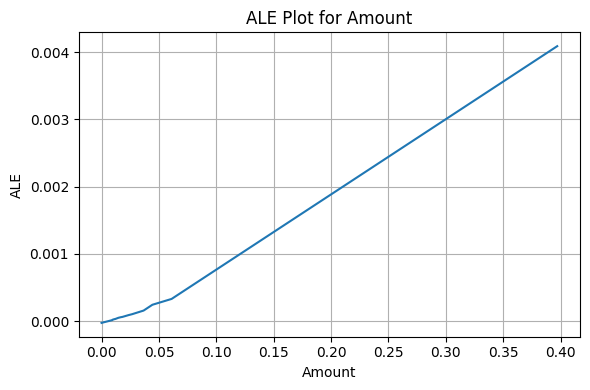

In [ ]:
# ALE Plot
explainer = ALE(silent_predict, feature_names=feature_names)
ale_explanation = explainer.explain(X_test_flat)

# Plot ALE curves for all features
for idx, feature in enumerate(feature_names):
    plt.figure(figsize=(6, 4))
    plt.plot(ale_explanation.feature_values[idx], ale_explanation.ale_values[idx], label='ALE')
    plt.xlabel(feature)
    plt.ylabel('ALE')
    plt.title(f'ALE Plot for {feature}')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

6231/6231 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step


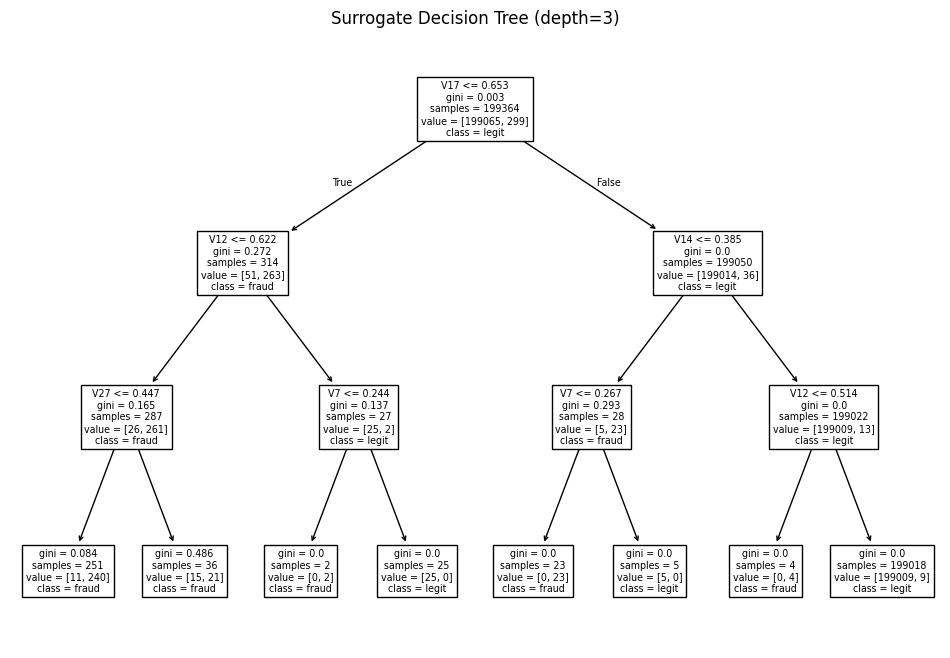

In [ ]:
# Surrogate model
y_train_pred = (model.predict(X_train).ravel() > 0.5).astype(int)
X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[2])
surrogate = DecisionTreeClassifier(max_depth=3, random_state=42)
surrogate.fit(X_train_flat, y_train_pred)
plt.figure(figsize=(12, 8))
plot_tree(surrogate, feature_names=df.drop(columns='Class').columns, class_names=['legit','fraud'], filled=False)
plt.title('Surrogate Decision Tree (depth=3)')
plt.show()

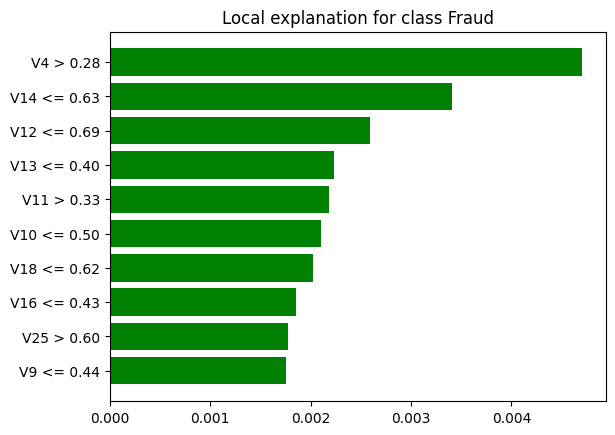

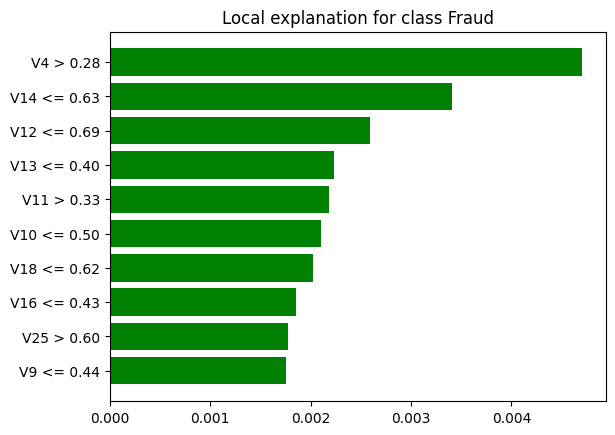

In [ ]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.reshape(X_train.shape[0], X_train.shape[2]),
    feature_names=feature_names,
    class_names=['Not Fraud', 'Fraud'],
    mode='classification'
)

i = 404 # Fraud case
lime_exp = lime_explainer.explain_instance(
    data_row=X_test_flat[i],
    predict_fn=lambda x: np.concatenate([1 - silent_predict(x), silent_predict(x)], axis=1)
)

lime_exp.as_pyplot_figure()

  0%|          | 0/10 [00:00<?, ?it/s]

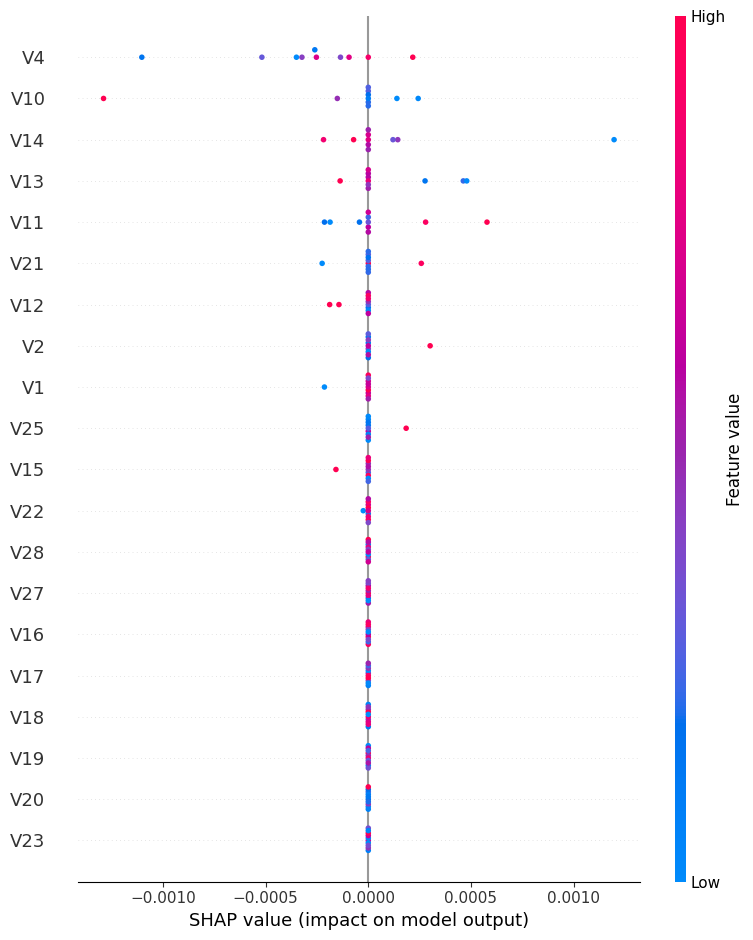

In [17]:
X_sample = X_test_flat[:100]

def silent_predict_shap(x):
    x_reshaped = x.reshape((x.shape[0], 1, x.shape[1]))
    preds = model.predict(x_reshaped, verbose=0)
    return preds.flatten()

explainer_kernel = shap.KernelExplainer(silent_predict_shap, X_sample)
shap_values_kernel = explainer_kernel.shap_values(X_sample[:10])
shap.summary_plot(shap_values_kernel, X_sample[:10], feature_names=feature_names)

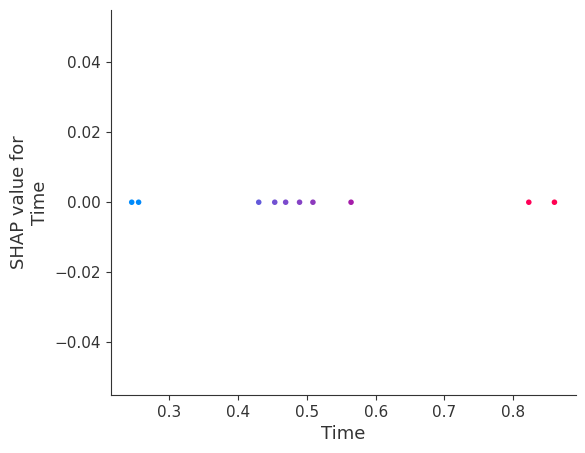

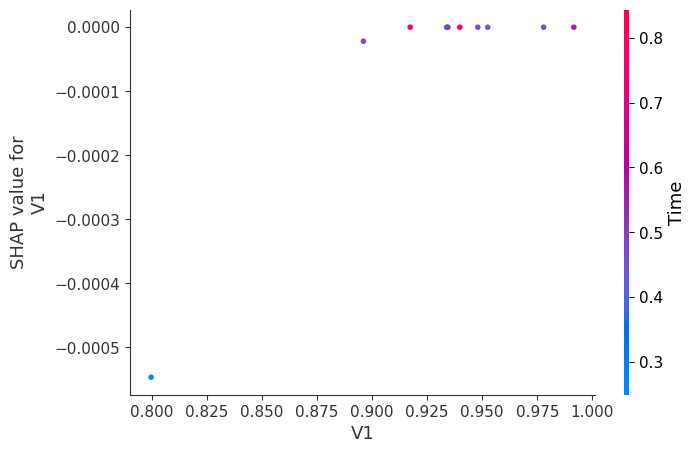

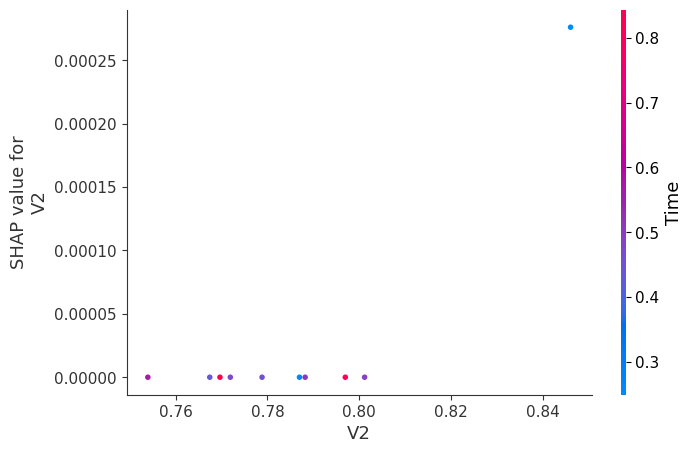

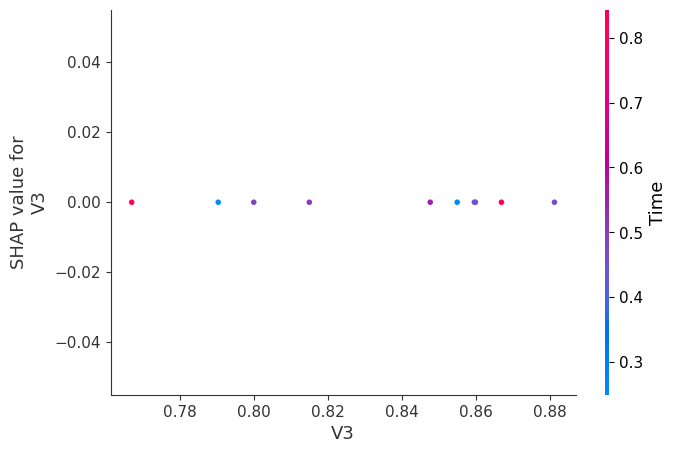

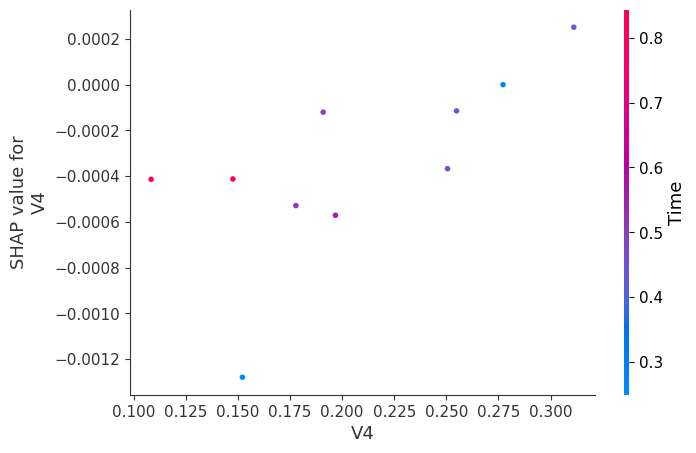

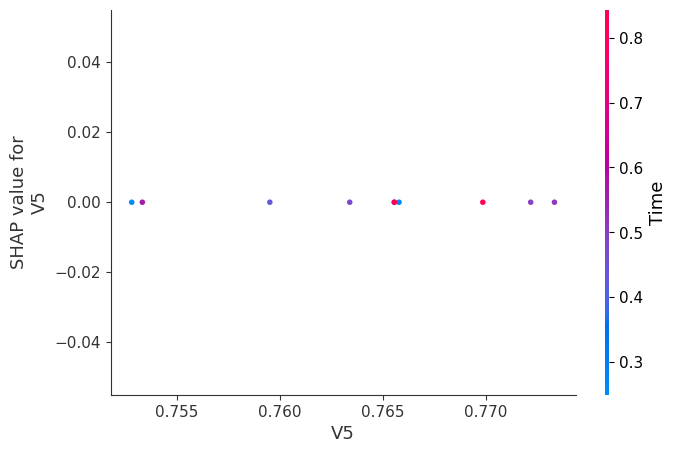

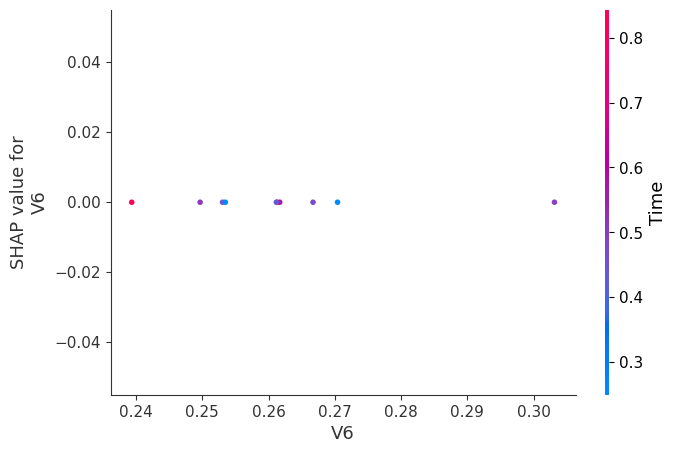

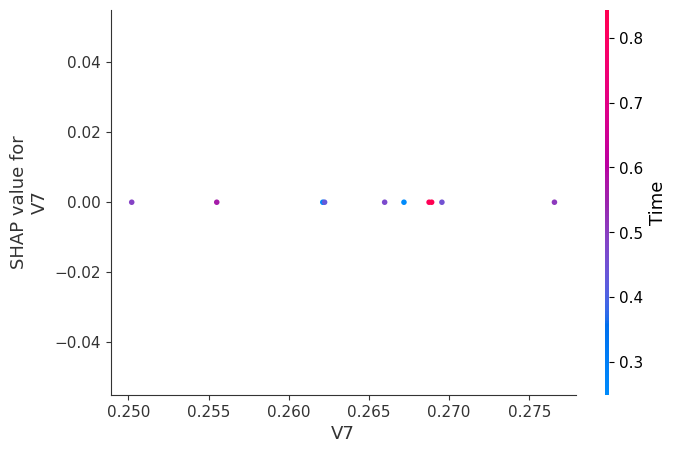

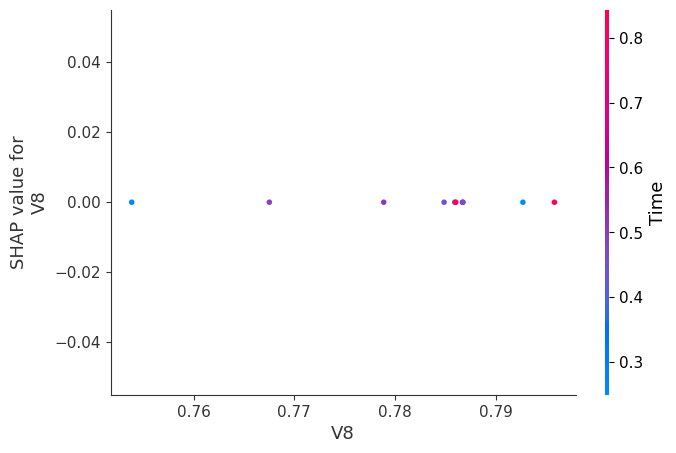

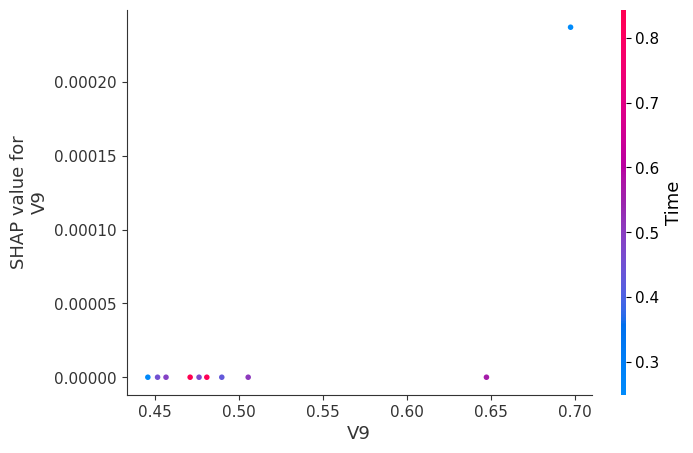

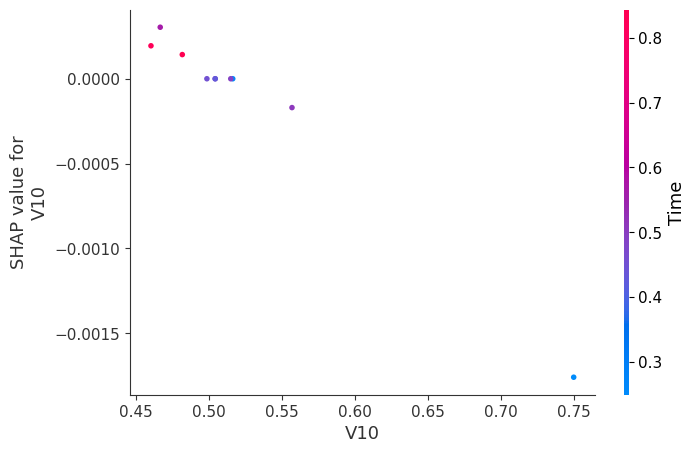

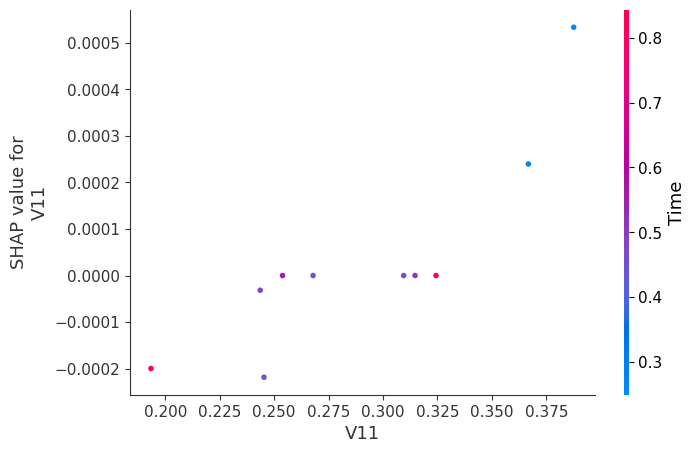

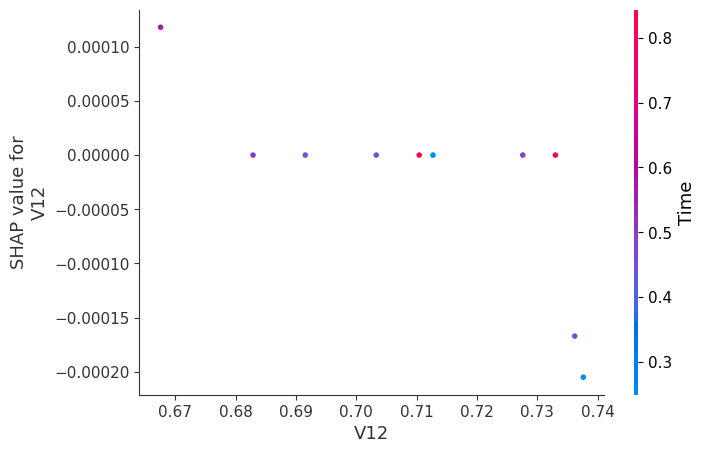

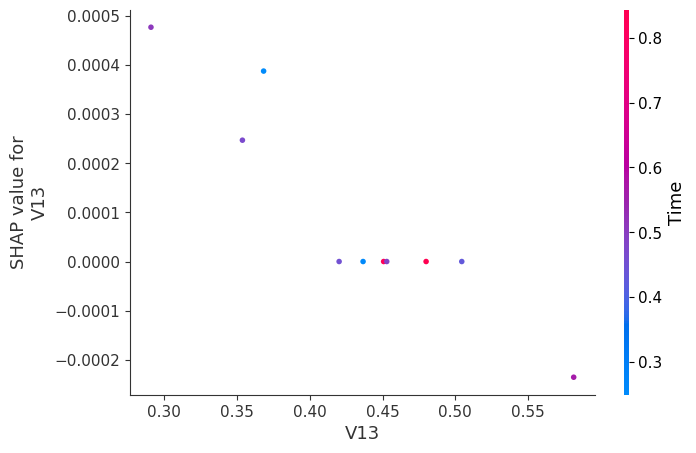

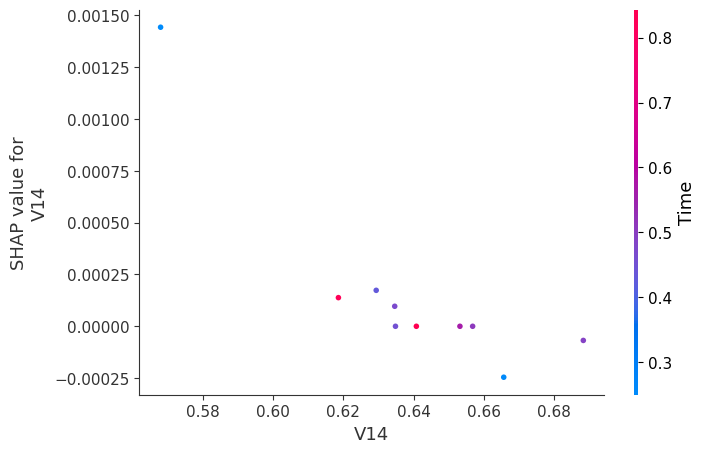

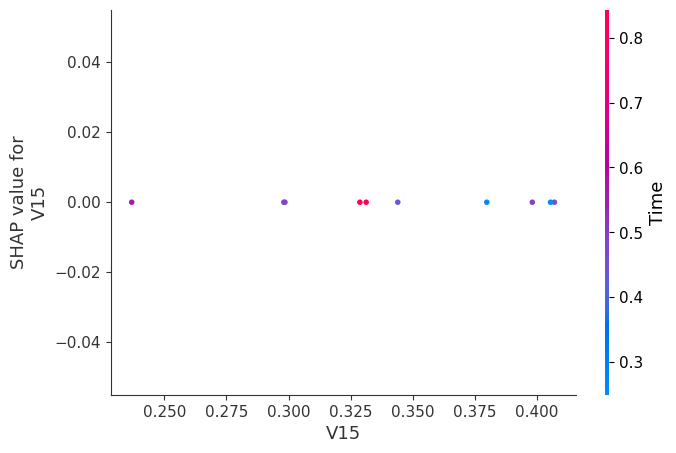

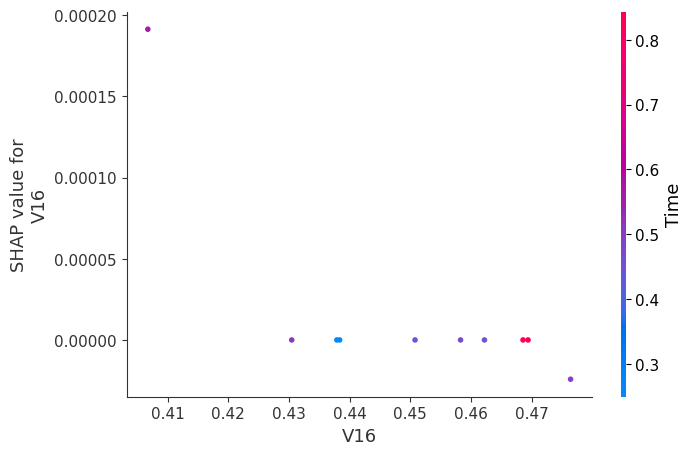

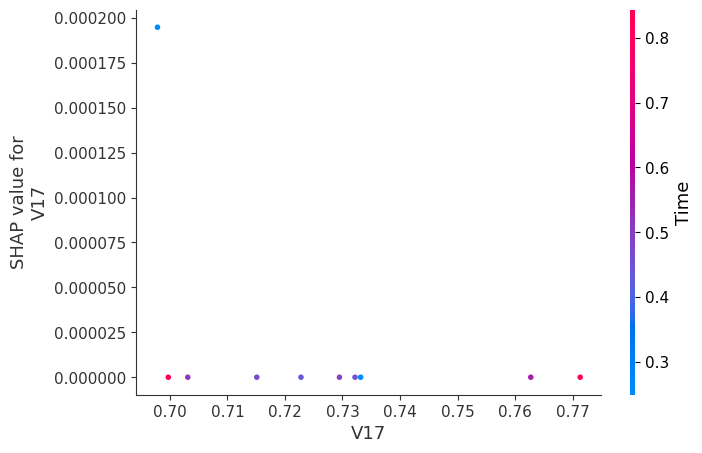

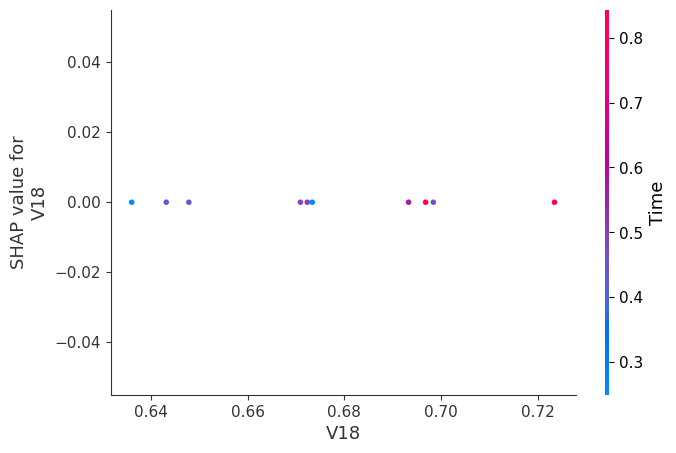

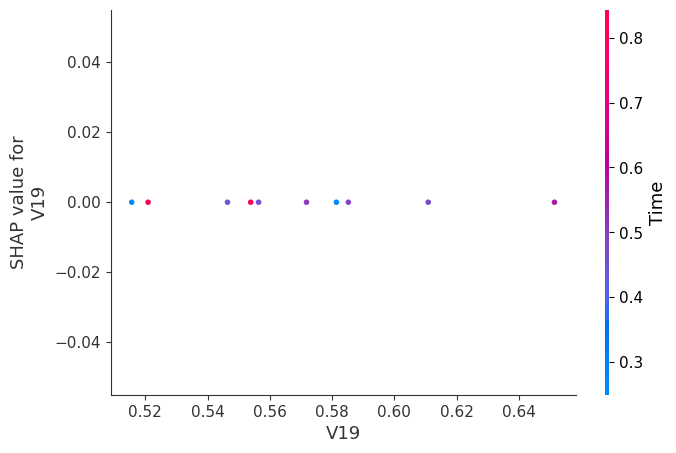

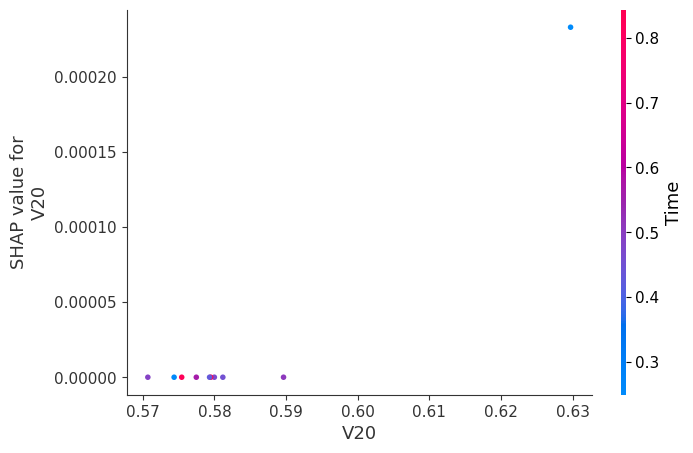

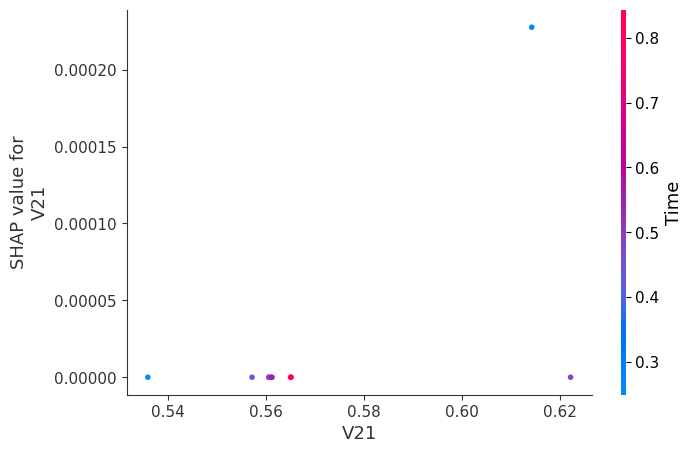

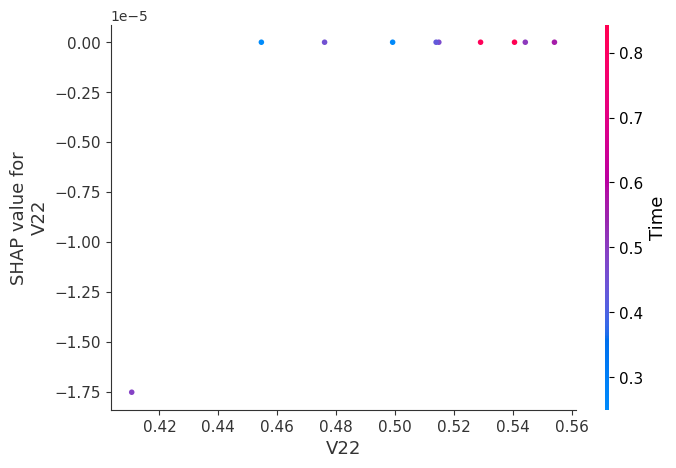

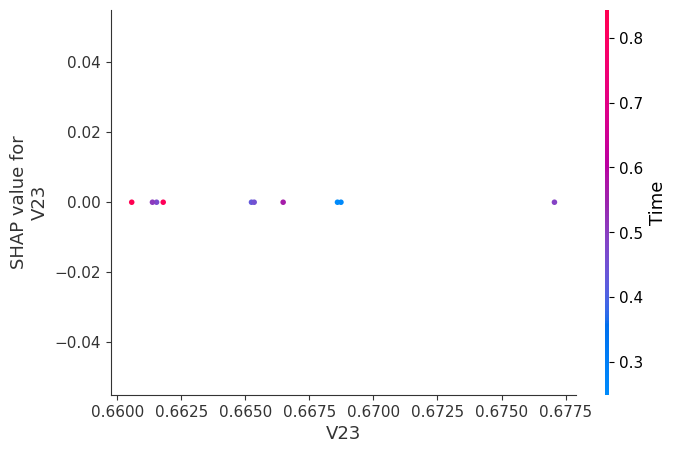

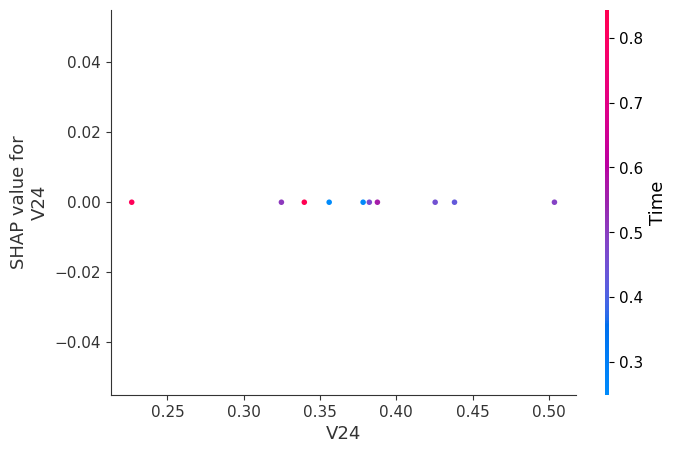

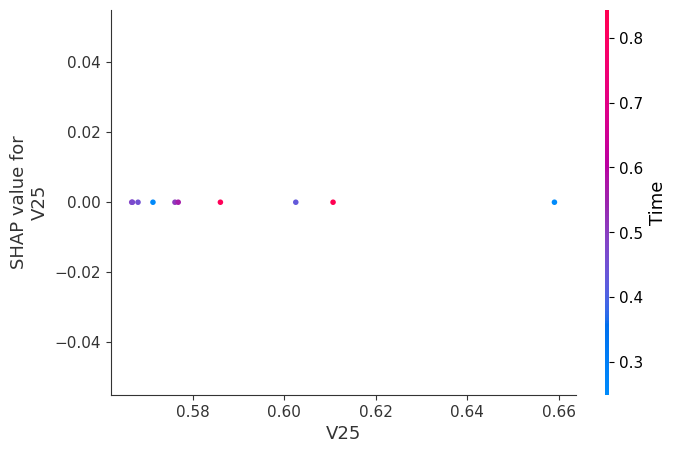

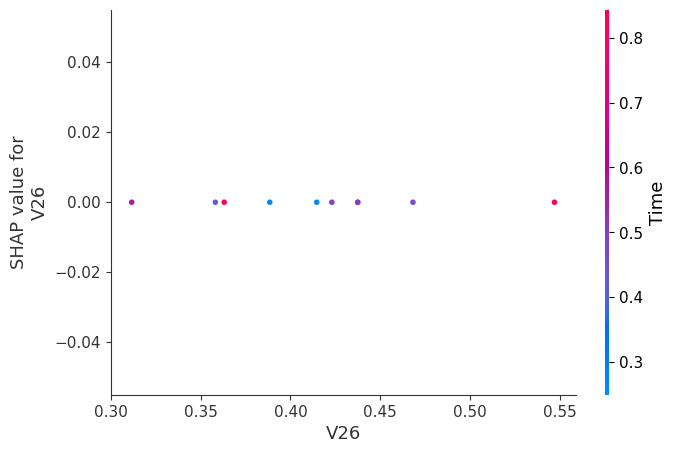

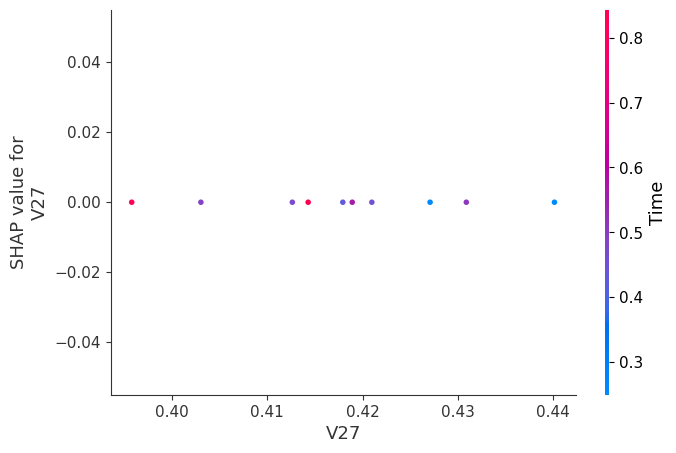

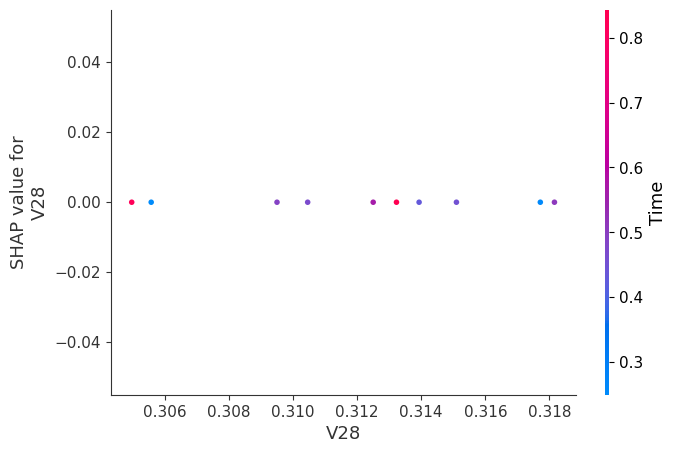

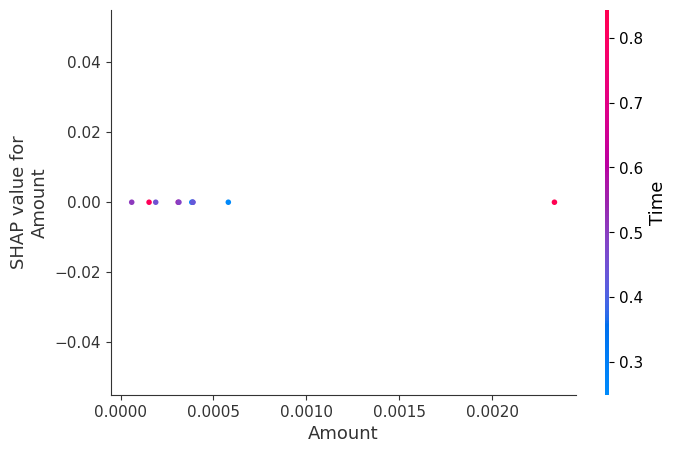

In [ ]:
for i, feat in enumerate(feature_names):
    shap.dependence_plot(i, shap_values_kernel, X_sample[:10], feature_names=feature_names)